<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/%D0%92%D1%81%D1%82%D1%83%D0%BF_%D0%B4%D0%BE_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%B8%D1%85_%D0%BC%D0%B5%D1%80%D0%B5%D0%B6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [1]:
import torch
import numpy as np

In [2]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [3]:
# Перетворюємо у тензори
inputs_tensor = torch.tensor(inputs)
targets_tensor = torch.tensor(targets)

# Виводимо результат
print("Inputs tensor:")
print(inputs_tensor)
print("\nTargets tensor:")
print(targets_tensor)

Inputs tensor:
tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])

Targets tensor:
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [4]:
torch.random.manual_seed(1)

In [5]:
# Кількість ознак (features)
n_features = inputs_tensor.shape[1]

# Ініціалізуємо ваги w і зсув b
w = torch.randn(n_features, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print("Weights (w):")
print(w)
print("\nBias (b):")
print(b)

Weights (w):
tensor([[0.6614],
        [0.2669],
        [0.0617]], requires_grad=True)

Bias (b):
tensor([0.6213], requires_grad=True)


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [6]:
# Визначаємо модель
def model(x, w, b):

  # Перетворюємо вектор у матрицю, якщо введено лише один рядок
  if x.dim() == 1:
    x = x.unsqueeze(0)  # робить із (D,) → (1, D)

  z = x @ w + b
  y_pred = 1 / (1 + torch.exp(-z))

  return y_pred

In [7]:
# Виклик функції
preds = model(inputs_tensor, w, b)
print("Predicted probabilities:\n", preds)

Predicted probabilities:
 tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)


In [8]:
# Порівняємо з таргетами
print(targets_tensor)

tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


**Спостереження**

Це підозріло, бо targets містять як 0, так і 1.

Причина - випадкові великі значення ваг і немасштабовані ознаки (всі ознаки мають значення 50–130, а ваги ≈0.6 - Xw+b виходить великим додатним числом).
Сигмоїда в цьому випадку насичується й повертає 1 для всіх прикладів.

4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [9]:
def binary_cross_entropy(predicted_probs, true_labels):

    eps = 1e-8  # щоб уникнути log(0)
    loss = - (true_labels * torch.log(predicted_probs + eps) +
              (1 - true_labels) * torch.log(1 - predicted_probs + eps))
    return torch.mean(loss)

In [10]:
# Обчислення втрат
loss_value = binary_cross_entropy(preds, targets_tensor)

print("Predicted probabilities:\n", preds)
print("\nBinary Cross-Entropy Loss:\n", loss_value.item())

Predicted probabilities:
 tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)

Binary Cross-Entropy Loss:
 7.368272304534912


5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [11]:
# Зворотний прохід
loss_value.backward()

print("Loss:", loss_value.item())
print("w.grad:\n", w.grad)
print("b.grad:\n", b.grad)

Loss: 7.368272304534912
w.grad:
 tensor([[1.0201e-21],
        [9.3628e-22],
        [6.0090e-22]])
b.grad:
 tensor([1.3974e-23])


**Cпостереження**

Ці майже нульові градієнти з’явилися через насичення сигмоїди: у мене ймовірності 1 для всіх зразків, тож p(1−p)=0. Якщо лосс рахується по ймовірностях (після sigmoid), автоград проходить через множник p(1−p) і чисельно «вбиває» градієнт.

**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [12]:
w.grad.zero_()
b.grad.zero_()
print(w.grad)
print(b.grad)

tensor([[0.],
        [0.],
        [0.]])
tensor([0.])


In [13]:
torch.random.manual_seed(1)
w = torch.randn(3, 1, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [14]:
# Виклик функції
preds = model(inputs_tensor, w, b)
print("Predicted probabilities:\n", preds)

Predicted probabilities:
 tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)


In [15]:
# Обчислення втрат
loss_value = binary_cross_entropy(preds, targets_tensor)

print("Predicted probabilities:\n", preds)
print("\nBinary Cross-Entropy Loss:\n", loss_value.item())

Predicted probabilities:
 tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)

Binary Cross-Entropy Loss:
 0.6829456686973572


In [16]:
# Зворотний прохід
loss_value.backward()

print("Loss:", loss_value.item())
print("w.grad:\n", w.grad)
print("b.grad:\n", b.grad)

Loss: 0.6829456686973572
w.grad:
 tensor([[ -5.4417],
        [-18.9853],
        [-10.0682]])
b.grad:
 tensor([-0.0794])


6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [17]:
# Лосс по логітах (BCEWithLogits)
criterion = torch.nn.BCEWithLogitsLoss(reduction='mean')

# Гіперпараметри GD
lr = 0.05
epochs = 1000

# Тренувальний цикл: forward -> loss -> backward -> update -> zero grads
for epoch in range(1, epochs + 1):
    # forward: логіти і лосс
    z = inputs_tensor @ w + b                  # (N,1)
    loss = criterion(z, targets_tensor)         # скаляр

    # backward: градієнти dL/dw, dL/db
    loss.backward()

    # update: w := w - lr * grad, b := b - lr * grad
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

        # обов'язково обнуляємо градієнти
        w.grad.zero_()
        b.grad.zero_()

    # трекінг (опційно)
    if epoch % 100 == 0 or epoch == 1:
        print(f"epoch {epoch:4d} | loss = {loss.item():.6f}")

# Фінальні передбачення
with torch.no_grad():
    z_final = inputs_tensor @ w + b
    probs   = torch.sigmoid(z_final)
    preds   = (probs >= 0.5).float()

print("\nFinal probabilities:\n", probs)
print("\nFinal predictions (>=0.5 → 1):\n", preds)
print("\nLearned w:\n", w)
print("\nLearned b:\n", b)

epoch    1 | loss = 0.682946
epoch  100 | loss = 0.000026
epoch  200 | loss = 0.000010
epoch  300 | loss = 0.000006
epoch  400 | loss = 0.000005
epoch  500 | loss = 0.000004
epoch  600 | loss = 0.000003
epoch  700 | loss = 0.000002
epoch  800 | loss = 0.000002
epoch  900 | loss = 0.000002
epoch 1000 | loss = 0.000002

Final probabilities:
 tensor([[8.8461e-06],
        [1.0000e+00],
        [1.0000e+00],
        [0.0000e+00],
        [1.0000e+00]])

Final predictions (>=0.5 → 1):
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Learned w:
 tensor([[-4.5234],
        [ 3.5353],
        [ 1.9018]], requires_grad=True)

Learned b:
 tensor([-0.0731], requires_grad=True)


**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [18]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [19]:
from torch.utils.data import TensorDataset

# Перетворення у тензори
inputs_tensor = torch.from_numpy(inputs)
targets_tensor = torch.from_numpy(targets)

# Створення TensorDataset
train_ds = TensorDataset(inputs_tensor, targets_tensor)

# Вивід перших 3 елементів
for i in range(3):
    x, y = train_ds[i]
    print(f"Sample {i}:")
    print("  inputs =", x)
    print("  target =", y)

Sample 0:
  inputs = tensor([73., 67., 43.])
  target = tensor([0.])
Sample 1:
  inputs = tensor([91., 88., 64.])
  target = tensor([1.])
Sample 2:
  inputs = tensor([ 87., 134.,  58.])
  target = tensor([1.])


8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [20]:
from torch.utils.data import DataLoader

# Створення DataLoader
train_dl = DataLoader(train_ds, batch_size=5, shuffle=True)

# Вивід першого батчу
for xb, yb in train_dl:
    print("Input batch (X):\n", xb)
    print("\nTarget batch (y):\n", yb)
    break  # показуємо лише перший батч

Input batch (X):
 tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.],
        [102.,  43.,  37.]])

Target batch (y):
 tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [21]:
import torch.nn as nn

# Клас логістичної регресії
class LogReg(nn.Module):
    def __init__(self):
        super(LogReg, self).__init__()
        self.linear = nn.Linear(3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.linear(x)
        out = self.sigmoid(out)
        return out

In [22]:
# Створення екземпляра моделі
model = LogReg()

print(model)

LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [23]:
import torch.nn.functional as F

# Оптимізатор SGD для параметрів моделі
opt = torch.optim.SGD(model.parameters(), lr=0.05)

# Функція втрат
loss_fn = F.binary_cross_entropy


X, y = train_ds.tensors


model.eval()
with torch.no_grad():
    preds = model(X)
    current_loss = loss_fn(preds, y)
    acc = ( (preds >= 0.5).float() == y ).float().mean().item()

print("Current loss:", current_loss.item())
print("Accuracy:", acc)

Current loss: 7.631152629852295
Accuracy: 0.20000000298023224


**Спостереження**

Зараз модель ще не навчилась (loss 7.63 і accuracy 0.2 - модель вгадує 1 з 5). Це типовий стан до тренування: ваги випадкові, сигмоїда насичена не в той бік.

11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

In [24]:
# Модифікована функцію fit для відстеження втрат
def fit_return_loss(num_epochs, model, loss_fn, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        # Ініціалізуємо акумулятор для втрат
        total_loss = 0

        for xb, yb in train_dl:
            # Генеруємо передбачення
            pred = model(xb)

            # Обчислюємо втрати
            loss = loss_fn(pred, yb)

            # Виконуємо градієнтний спуск
            loss.backward()
            opt.step()
            opt.zero_grad()

            # Накопичуємо втрати
            total_loss += loss.item()

        # Обчислюємо середні втрати для епохи
        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)

        # Виводимо підсумок епохи
        if (epoch + 1) % 10 == 0:
          print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses

In [25]:
# тренування
num_epochs = 1000
losses = fit_return_loss(num_epochs, model, loss_fn, opt, train_dl)

Epoch [10/1000], Loss: 40.0000
Epoch [20/1000], Loss: 40.0000
Epoch [30/1000], Loss: 40.0000
Epoch [40/1000], Loss: 40.0000
Epoch [50/1000], Loss: 40.0000
Epoch [60/1000], Loss: 40.0000
Epoch [70/1000], Loss: 40.0000
Epoch [80/1000], Loss: 40.0000
Epoch [90/1000], Loss: 40.0000
Epoch [100/1000], Loss: 40.0000
Epoch [110/1000], Loss: 40.0000
Epoch [120/1000], Loss: 40.0000
Epoch [130/1000], Loss: 40.0000
Epoch [140/1000], Loss: 40.0000
Epoch [150/1000], Loss: 40.0000
Epoch [160/1000], Loss: 40.0000
Epoch [170/1000], Loss: 40.0000
Epoch [180/1000], Loss: 40.0000
Epoch [190/1000], Loss: 40.0000
Epoch [200/1000], Loss: 40.0000
Epoch [210/1000], Loss: 40.0000
Epoch [220/1000], Loss: 40.0000
Epoch [230/1000], Loss: 40.0000
Epoch [240/1000], Loss: 40.0000
Epoch [250/1000], Loss: 40.0000
Epoch [260/1000], Loss: 40.0000
Epoch [270/1000], Loss: 40.0000
Epoch [280/1000], Loss: 40.0000
Epoch [290/1000], Loss: 40.0000
Epoch [300/1000], Loss: 40.0000
Epoch [310/1000], Loss: 40.0000
Epoch [320/1000],

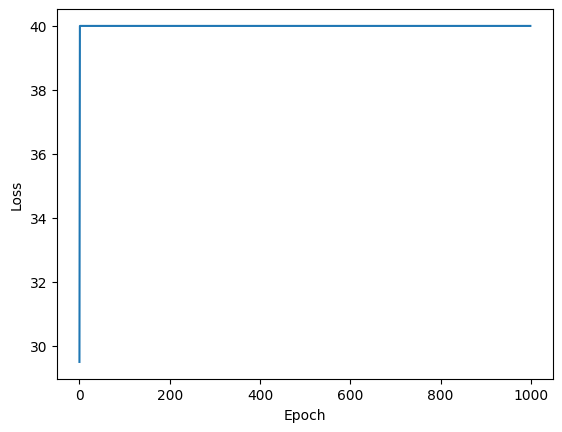

In [26]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

**loss не змінюється - отже модель фактично не навчається.
Причини: або градієнти не оновлюють параметри, або сигмоїда насичена (градієнти ≈ 0).**

In [27]:
# Клас моделі без Sigmoid
class LogRegNoSigmoid(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)
    def forward(self, x):
        return self.linear(x)

In [28]:
# Модель, лосс, оптимізатор
model = LogRegNoSigmoid()
criterion = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.05)

In [29]:
# Тренування
losses = fit_return_loss(1000, model, criterion, opt, train_dl)

Epoch [10/1000], Loss: 2.5585
Epoch [20/1000], Loss: 0.4109
Epoch [30/1000], Loss: 0.2400
Epoch [40/1000], Loss: 0.2034
Epoch [50/1000], Loss: 0.1900
Epoch [60/1000], Loss: 0.3205
Epoch [70/1000], Loss: 0.1644
Epoch [80/1000], Loss: 0.1328
Epoch [90/1000], Loss: 0.0726
Epoch [100/1000], Loss: 0.0952
Epoch [110/1000], Loss: 0.0861
Epoch [120/1000], Loss: 0.0882
Epoch [130/1000], Loss: 0.0460
Epoch [140/1000], Loss: 0.0529
Epoch [150/1000], Loss: 0.0429
Epoch [160/1000], Loss: 0.0463
Epoch [170/1000], Loss: 0.0309
Epoch [180/1000], Loss: 0.0286
Epoch [190/1000], Loss: 0.0304
Epoch [200/1000], Loss: 0.0277
Epoch [210/1000], Loss: 0.0227
Epoch [220/1000], Loss: 0.0251
Epoch [230/1000], Loss: 0.0190
Epoch [240/1000], Loss: 0.0208
Epoch [250/1000], Loss: 0.0176
Epoch [260/1000], Loss: 0.0195
Epoch [270/1000], Loss: 0.0160
Epoch [280/1000], Loss: 0.0145
Epoch [290/1000], Loss: 0.0140
Epoch [300/1000], Loss: 0.0131
Epoch [310/1000], Loss: 0.0120
Epoch [320/1000], Loss: 0.0116
Epoch [330/1000],

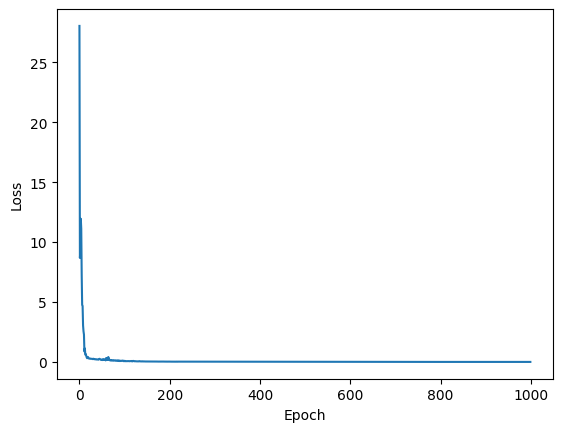

In [30]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

**Спостереження**

Протягом перших 100 епох loss стрімко падає майже до нуля. Після цього стабілізується - модель досягла мінімуму функції втрат.

In [31]:
# Фінальні передбачення
model.eval()
with torch.no_grad():
    logits = model(X)
    probs = torch.sigmoid(logits)  # тепер вручну застосовуємо сигмоїду для ймовірностей
    preds = (probs >= 0.5).float()
    acc = (preds.eq(y)).float().mean().item()

print("\nFinal probabilities:\n", probs)
print("\nFinal predictions:\n", preds)
print("\nTargets:\n", y)
print(f"\nAccuracy: {acc:.4f}")


Final probabilities:
 tensor([[4.2079e-03],
        [9.9702e-01],
        [9.9995e-01],
        [1.5125e-17],
        [1.0000e+00],
        [4.2079e-03],
        [9.9702e-01],
        [9.9995e-01],
        [1.5125e-17],
        [1.0000e+00],
        [4.2079e-03],
        [9.9702e-01],
        [9.9995e-01],
        [1.5125e-17],
        [1.0000e+00]])

Final predictions:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Targets:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Accuracy: 1.0000


**Спостереження**

Accuracy = 1 - усі приклади класифіковані правильно.

Ймовірності майже 0 або майже 1 - сильна впевненість (дані лінійно відокремні).

Це підтверджує, що перехід на логіти + BCEWithLogitsLoss прибрав проблему насичення та «замороженого» loss